# Workshop D.2: Evaluating Learned Representations
## Notebook 5.a — Informativeness of Representations

This notebook evaluates linear informativeness of frozen ResNet representations on STL-10 using the Representation Evaluation Recipe Card.


**Learning Objectives:**- Compare pretrained vs. random representations

- Learn the standard recipe for evaluating representation properties- Test whether task-relevant and factor-relevant information is linearly accessible
- Evaluate **informativeness**: Can we recover useful information from z?

In [1]:
# --- Imports: standard libs, numpy/pandas, plotting, torch, torchvision, sklearn
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
from torchvision.models import (resnet18, resnet34, ResNet18_Weights, ResNet34_Weights)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

# Suppress noisy warnings in notebook output
warnings.filterwarnings("ignore")

---
## Step 1: Load the Dataset

Define a small, editable config dataclass so the notebook runs quickly on a laptop/Colab.

**Recipe Card:** Load the Dataset of interest (evaluation dataset)  ### Configuration

$\mathcal{D} = \{x_i, y_i\}_{i=1}^N$

- **Factors of variation:** Brightness and hue of original images

For this notebook, we use STL-10 with controlled factors:- **Task:** Object class (10 classes)

In [2]:
@dataclass
class Config:
    # Data
    data_root: str = "./data"
    dataset_name: str = "STL10"
    image_size: int = 224

    # Keep these modest for a laptop/Colab. Increase later for stronger results.
    num_train_samples: int = 1000
    num_test_samples: int = 500

    # Dataloader
    batch_size: int = 64
    num_workers: int = 2

    # Models
    model_names: Tuple[str, ...] = ("resnet18", "resnet34", "resnet18_random")

    # Controlled factors for informativeness
    brightness_values: Tuple[float, ...] = (0.6, 0.8, 1.0, 1.2, 1.4)
    hue_values: Tuple[float, ...] = (-0.2, -0.1, 0.0, 0.1, 0.2)

    # Reproducibility
    random_seed: int = 42

cfg = Config()

# Quick sanity print
print("Config: data_root=", cfg.data_root, "image_size=", cfg.image_size)

Config: data_root= ./data image_size= 224


### Reproducibility & Device
Set random seeds and choose CPU/GPU device.

In [3]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility across numpy, random, and torch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.random_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Plot Style & Colors
Configure matplotlib and color mappings used for plots.

In [4]:
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

model_colors = {
    "resnet18": "#1f77b4",
    "resnet34": "#ff7f0e",
    "resnet18_random": "#7f7f7f",
}

task_colors = {
    "class": "#4c72b0",
    "brightness": "#55a868",
    "hue": "#c44e52",
}

### ImageNet Normalization Constants
Used before feeding images to the pretrained ResNets.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

### Step 2: Define Task-Specific Functions & Transformations


**Recipe Card:** Define optional transformations  Resize, tensorize, and normalize images for the frozen ResNet encoder.

$x_i' = T_\alpha(x_i)$**Transform: STL-10 Encoder Transform**



Examples: noise, crop, rotation, brightness shift, gene dropout, domain shift, translation.For this notebook, we define an encoder-ready transform and factor extraction functions.


In [6]:
class STL10EncoderTransform:
    """Resize, tensorize, and normalize images for the encoder."""
    def __init__(self, image_size: int = 224):
        self.image_size = image_size
        self.resize = transforms.Resize((image_size, image_size))
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __call__(self, img):
        img = self.resize(img)
        img = self.to_tensor(img)
        img = self.normalize(img)
        return img

### Dataset Helpers
Small helpers to create reproducible subsets and DataLoaders.

In [7]:
def make_subset(dataset, n_samples: int, seed: int) -> Subset:
    """Return a reproducible random subset of a dataset."""
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, len(dataset))
    indices = rng.choice(len(dataset), size=n_samples, replace=False)
    return Subset(dataset, indices.tolist())

def make_stl10_dataset(split: str):
    transform = STL10EncoderTransform(image_size=cfg.image_size)
    dataset = datasets.STL10(root=cfg.data_root, split=split, download=True, transform=transform)
    return dataset

def make_raw_stl10_dataset(split: str):
    dataset = datasets.STL10(root=cfg.data_root, split=split, download=True, transform=None)
    return dataset

def make_dataloader(dataset, shuffle: bool = False) -> DataLoader:
    return DataLoader(dataset, batch_size=cfg.batch_size, shuffle=shuffle, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

### Load Datasets (Subsets)
Create small reproducible train/test subsets for faster runs.

In [8]:
clean_train_full = make_stl10_dataset(split="train")
clean_test_full = make_stl10_dataset(split="test")

train_subset = make_subset(clean_train_full, n_samples=cfg.num_train_samples, seed=cfg.random_seed)
test_subset = make_subset(clean_test_full, n_samples=cfg.num_test_samples, seed=cfg.random_seed + 1)

train_loader = make_dataloader(train_subset, shuffle=False)
test_loader = make_dataloader(test_subset, shuffle=False)

print(f"Train subset size: {len(train_subset)}")
print(f"Test subset size:  {len(test_subset)}")

Files already downloaded and verified
Files already downloaded and verified
Train subset size: 1000
Test subset size:  500


---
## Step 3: Encoder & Representation

Wrap torchvision ResNet to expose the avgpool 512-d embedding and freeze parameters.

**Recipe Card:** Encoder and representation  ### ResNet Encoder Wrapper

-Load an encoder: $f_\theta$  

-Choose the layer used as the representation: $z_i = f_\theta(x_i)$  - Freeze encoder: `requires_grad = False` in PyTorch

-Examples: penultimate layer, bottleneck, CLS token, pooled graph/set embedding.- Representation layer: Average pooled output (512-d)

- Encoder: Frozen pretrained ResNet (resnet18, resnet34) or random ResNet18
**For this notebook:**

In [10]:
class ResNetAvgPoolEncoder(nn.Module):
    """Return 512-d avgpool features from a torchvision ResNet."""
    def __init__(self, resnet_model: nn.Module):
        super().__init__()
        # Keep all layers except final fully-connected classifier
        self.backbone = nn.Sequential(*list(resnet_model.children())[:-1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.backbone(x)  # [B, 512, 1, 1]
        z = torch.flatten(z, start_dim=1)  # [B, 512]
        return z

def get_resnet_encoder(model_name: str, device: torch.device) -> nn.Module:
    if model_name == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    elif model_name == "resnet34":
        model = resnet34(weights=ResNet34_Weights.DEFAULT)
    elif model_name == "resnet18_random":
        model = resnet18(weights=None)
    else:
        raise ValueError("model_name must be one of: 'resnet18', 'resnet34', 'resnet18_random'.")

    encoder = ResNetAvgPoolEncoder(model)
    # Freeze encoder and move to device
    encoder.eval()
    for p in encoder.parameters(): p.requires_grad = False
    return encoder.to(device)

### Embedding Extraction
Utility to run the frozen encoder over a DataLoader and return numpy arrays.

In [11]:
@torch.no_grad()
def extract_embeddings(encoder: nn.Module, dataloader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    encoder.eval()
    all_Z, all_y = [], []
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        z_batch = encoder(x_batch)
        z_batch = z_batch.detach().cpu().numpy()
        all_Z.append(z_batch)
        all_y.append(np.asarray(y_batch))
    Z = np.concatenate(all_Z, axis=0)
    y = np.concatenate(all_y, axis=0)
    return Z, y

---
## Step 4: Probe Model

Functions to train logistic regression for class probe and Ridge regression for factor probes.

**Recipe Card:** Train a small probe $g_{\theta_p}$ on top of the representation output  ### Probe Models (Linear Probes)

$\hat{v}_i = g_{\theta_p}(z_i)$

The probe asks: "Is this information accessible from $z$?"

where $v_i$ is the property we want to test.

In [12]:
def train_classification_probe(Z_train: np.ndarray, y_train: np.ndarray, Z_test: np.ndarray, y_test: np.ndarray):
    scaler = StandardScaler()
    Z_train_scaled = scaler.fit_transform(Z_train)
    Z_test_scaled = scaler.transform(Z_test)
    clf = LogisticRegression(max_iter=3000, n_jobs=-1, multi_class="auto")
    clf.fit(Z_train_scaled, y_train)
    train_pred = clf.predict(Z_train_scaled)
    test_pred = clf.predict(Z_test_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    return {
        "train_accuracy": float(train_acc),
        "test_accuracy": float(test_acc),
        "scaler": scaler,
        "probe": clf,
        "test_predictions": test_pred,
    }

def train_regression_probe(Z_train: np.ndarray, target_train: np.ndarray, Z_test: np.ndarray, target_test: np.ndarray):
    scaler = StandardScaler()
    Z_train_scaled = scaler.fit_transform(Z_train)
    Z_test_scaled = scaler.transform(Z_test)
    reg = Ridge(alpha=1.0)
    reg.fit(Z_train_scaled, target_train)
    train_pred = reg.predict(Z_train_scaled)
    test_pred = reg.predict(Z_test_scaled)
    train_r2 = r2_score(target_train, train_pred)
    test_r2 = r2_score(target_test, test_pred)
    train_mae = mean_absolute_error(target_train, train_pred)
    test_mae = mean_absolute_error(target_test, test_pred)
    return {
        "train_r2": float(train_r2),
        "test_r2": float(test_r2),
        "train_mae": float(train_mae),
        "test_mae": float(test_mae),
        "scaler": scaler,
        "probe": reg,
        "test_predictions": test_pred,
        "test_targets": target_test,
    }

---
## Step 5.a: Evaluation Plugin — Informativeness

Create embeddings and targets from the untouched STL-10 images, then probe whether brightness and hue are linearly accessible from the frozen representation.

**Recipe Card (5.a Informativeness):**### Original-Image Factor Embeddings



**Question:** Can we recover useful information from $z$?3. **Hue information:** Hue/color of the original image (regression task)

2. **Brightness information:** Brightness level of the original image (regression task)

**Method:** Usually done by comparing $v = FV(x)$ vs. $\hat{v} = g_p(z)$1. **Class information:** Object class label (10-way classification task)

We evaluate informativeness of:

In [13]:
class STL10OriginalFactorDataset(Dataset):
    """Pair encoder-ready images with original-image brightness or hue targets."""
    def __init__(self, split: str, subset_indices: List[int], target_type: str):
        self.dataset = make_raw_stl10_dataset(split=split)
        self.indices = list(subset_indices)
        self.target_type = target_type
        self.encoder_transform = STL10EncoderTransform(image_size=cfg.image_size)
        if target_type not in ["brightness", "hue"]:
            raise ValueError("target_type must be 'brightness' or 'hue'.")

    def __len__(self) -> int:
        return len(self.indices)

    def _compute_target(self, img) -> float:
        rgb = np.asarray(img.convert("RGB"), dtype=np.float32) / 255.0
        if self.target_type == "brightness":
            return float(rgb.mean())
        hsv = np.asarray(img.convert("HSV"), dtype=np.float32) / 255.0
        return float(hsv[..., 0].mean())

    def __getitem__(self, idx: int):
        img, _ = self.dataset[self.indices[idx]]
        x = self.encoder_transform(img)
        target = self._compute_target(img)
        return x, target

def build_original_factor_embedding_dataset(encoder: nn.Module, split: str, base_subset_indices: List[int], target_type: str, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    dataset_subset = STL10OriginalFactorDataset(split=split, subset_indices=base_subset_indices, target_type=target_type)
    loader = make_dataloader(dataset_subset, shuffle=False)
    Z_all, target_all = extract_embeddings(encoder=encoder, dataloader=loader, device=device)
    return Z_all, target_all

def get_subset_indices(subset: Subset) -> List[int]:
    return list(subset.indices)

train_indices = get_subset_indices(train_subset)
test_indices = get_subset_indices(test_subset)

### Run Evaluations
Loop over models, extract embeddings, train probes for class and original-image brightness/hue, and store results.

In [14]:
all_results = []
prediction_store = {}
feature_store = {}

for model_name in cfg.model_names:
    print("\n" + "=" * 80)
    print(f"Running model: {model_name}")
    print("=" * 80)
    encoder = get_resnet_encoder(model_name, device)

    # A. Class informativeness
    print("Extracting clean embeddings...")
    Z_train_clean, y_train = extract_embeddings(encoder, train_loader, device)
    Z_test_clean, y_test = extract_embeddings(encoder, test_loader, device)
    feature_store[model_name] = {
        "Z_train_clean": Z_train_clean,
        "y_train": y_train,
        "Z_test_clean": Z_test_clean,
        "y_test": y_test,
    }
    print("Training class linear probe...")
    class_result = train_classification_probe(Z_train_clean, y_train, Z_test_clean, y_test)
    all_results.append({
        "Model": model_name,
        "Task": "class",
        "Target": "STL-10 class",
        "Embedding Dim": Z_train_clean.shape[1],
        "Train Score": class_result["train_accuracy"],
        "Test Score": class_result["test_accuracy"],
        "Test MAE": np.nan,
        "Metric": "accuracy",
    })

    # B. Brightness informativeness from original images
    print("Building original-image brightness embeddings...")
    Z_train_brightness, target_train_brightness = build_original_factor_embedding_dataset(
        encoder=encoder,
        split="train",
        base_subset_indices=train_indices,
        target_type="brightness",
        device=device,
    )
    Z_test_brightness, target_test_brightness = build_original_factor_embedding_dataset(
        encoder=encoder,
        split="test",
        base_subset_indices=test_indices,
        target_type="brightness",
        device=device,
    )
    print("Training brightness regression probe...")
    brightness_result = train_regression_probe(Z_train_brightness, target_train_brightness, Z_test_brightness, target_test_brightness)
    prediction_store[(model_name, "brightness")] = {
        "target": brightness_result["test_targets"],
        "prediction": brightness_result["test_predictions"],
    }
    all_results.append({
        "Model": model_name,
        "Task": "brightness",
        "Target": "brightness from original image",
        "Embedding Dim": Z_train_brightness.shape[1],
        "Train Score": brightness_result["train_r2"],
        "Test Score": brightness_result["test_r2"],
        "Test MAE": brightness_result["test_mae"],
        "Metric": "R2",
    })

    # C. Hue informativeness from original images
    print("Building original-image hue embeddings...")
    Z_train_hue, target_train_hue = build_original_factor_embedding_dataset(
        encoder=encoder,
        split="train",
        base_subset_indices=train_indices,
        target_type="hue",
        device=device,
    )
    Z_test_hue, target_test_hue = build_original_factor_embedding_dataset(
        encoder=encoder,
        split="test",
        base_subset_indices=test_indices,
        target_type="hue",
        device=device,
    )
    print("Training hue regression probe...")
    hue_result = train_regression_probe(Z_train_hue, target_train_hue, Z_test_hue, target_test_hue)
    prediction_store[(model_name, "hue")] = {
        "target": hue_result["test_targets"],
        "prediction": hue_result["test_predictions"],
    }
    all_results.append({
        "Model": model_name,
        "Task": "hue",
        "Target": "hue from original image",
        "Embedding Dim": Z_train_hue.shape[1],
        "Train Score": hue_result["train_r2"],
        "Test Score": hue_result["test_r2"],
        "Test MAE": hue_result["test_mae"],
        "Metric": "R2",
    })

# After loop, assemble results dataframe
results_df = pd.DataFrame(all_results)
print("\nFull informativeness results:")
display(results_df) if "display" in globals() else print(results_df)


Running model: resnet18
Extracting clean embeddings...
Training class linear probe...
Building original-image brightness embeddings...
Files already downloaded and verified
Files already downloaded and verified
Training brightness regression probe...
Building original-image hue embeddings...
Files already downloaded and verified
Files already downloaded and verified
Training hue regression probe...

Running model: resnet34
Extracting clean embeddings...
Training class linear probe...
Building original-image brightness embeddings...
Files already downloaded and verified
Files already downloaded and verified
Training brightness regression probe...
Building original-image hue embeddings...
Files already downloaded and verified
Files already downloaded and verified
Training hue regression probe...

Running model: resnet18_random
Extracting clean embeddings...
Training class linear probe...
Building original-image brightness embeddings...
Files already downloaded and verified
Files already

### Summary Table and Plots
Build a compact per-model summary, then show class and three-task summary plots.

In [15]:
def build_summary_table(results_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_name in cfg.model_names:
        sub = results_df[results_df["Model"] == model_name]
        class_row = sub[sub["Task"] == "class"].iloc[0]
        brightness_row = sub[sub["Task"] == "brightness"].iloc[0]
        hue_row = sub[sub["Task"] == "hue"].iloc[0]
        rows.append({
            "Model": model_name,
            "Embedding Dim": int(class_row["Embedding Dim"]),
            "Class Test Accuracy": class_row["Test Score"],
            "Brightness Test R2": brightness_row["Test Score"],
            "Brightness Test MAE": brightness_row["Test MAE"],
            "Hue Test R2": hue_row["Test Score"],
            "Hue Test MAE": hue_row["Test MAE"],
        })
    return pd.DataFrame(rows)

summary_df = build_summary_table(results_df)
print("\nFinal summary table:")
display(summary_df) if "display" in globals() else print(summary_df)


Final summary table:
             Model  Embedding Dim  Class Test Accuracy  Brightness Test R2  \
0         resnet18            512                0.946            0.453647   
1         resnet34            512                0.944            0.570647   
2  resnet18_random            512                0.344            0.985444   

   Brightness Test MAE  Hue Test R2  Hue Test MAE  
0             0.066594     0.167012      0.106668  
1             0.058149     0.238435      0.102202  
2             0.010755     0.453610      0.085625  


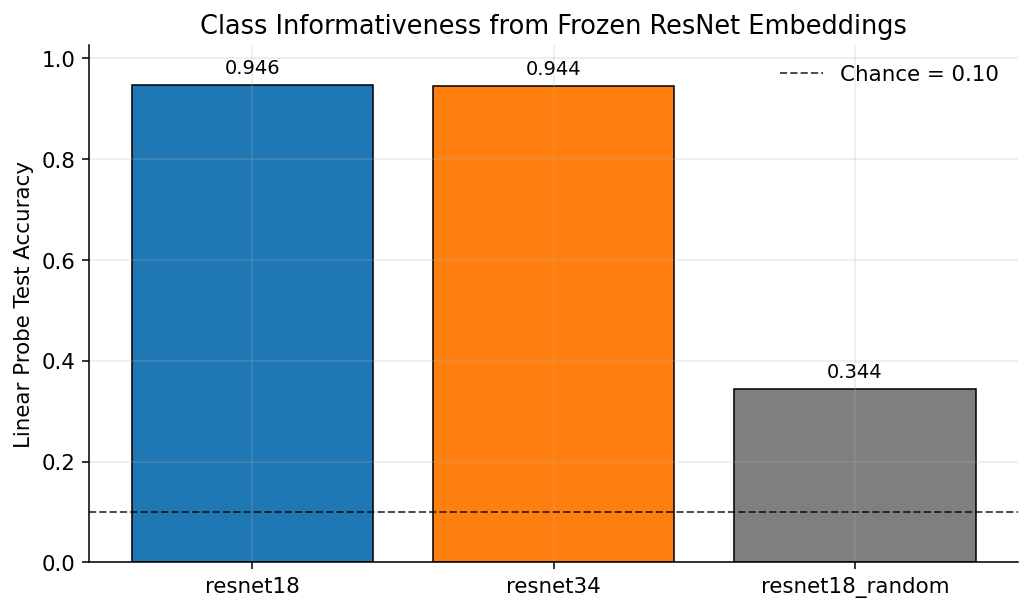

In [16]:
def plot_class_informativeness(summary_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    models = summary_df["Model"].tolist()
    values = summary_df["Class Test Accuracy"].values
    colors = [model_colors[m] for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor="black", linewidth=0.8)
    ax.axhline(0.10, linestyle="--", color="black", linewidth=1, alpha=0.7, label="Chance = 0.10")
    ax.set_ylim(0, max(1.0, values.max() + 0.08))
    ax.set_ylabel("Linear Probe Test Accuracy")
    ax.set_title("Class Informativeness from Frozen ResNet Embeddings")
    ax.legend(frameon=False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_class_informativeness(summary_df)

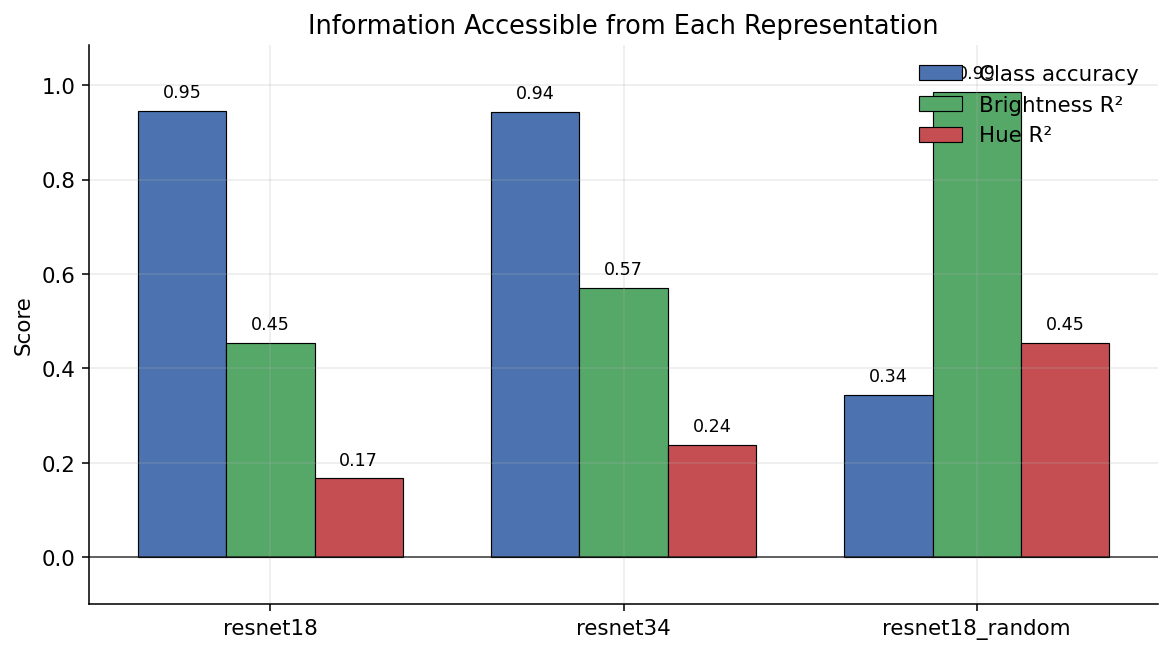

In [17]:
def plot_three_task_summary(summary_df: pd.DataFrame) -> None:
    models = summary_df["Model"].tolist()
    class_scores = summary_df["Class Test Accuracy"].values
    brightness_scores = summary_df["Brightness Test R2"].values
    hue_scores = summary_df["Hue Test R2"].values
    x = np.arange(len(models))
    width = 0.25
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    bars1 = ax.bar(x - width, class_scores, width, label="Class accuracy", color=task_colors["class"], edgecolor="black", linewidth=0.6)
    bars2 = ax.bar(x, brightness_scores, width, label="Brightness R²", color=task_colors["brightness"], edgecolor="black", linewidth=0.6)
    bars3 = ax.bar(x + width, hue_scores, width, label="Hue R²", color=task_colors["hue"], edgecolor="black", linewidth=0.6)
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("Score")
    ax.set_title("Information Accessible from Each Representation")
    ax.legend(frameon=False)
    all_vals = np.concatenate([class_scores, brightness_scores, hue_scores])
    y_min = min(-0.1, all_vals.min() - 0.1)
    y_max = max(1.0, all_vals.max() + 0.1)
    ax.set_ylim(y_min, y_max)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            val = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02 if val >= 0 else val - 0.05, f"{val:.2f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_three_task_summary(summary_df)

### Factor Prediction Scatter Plots
Scatter plots comparing true vs predicted factor values for brightness and hue.

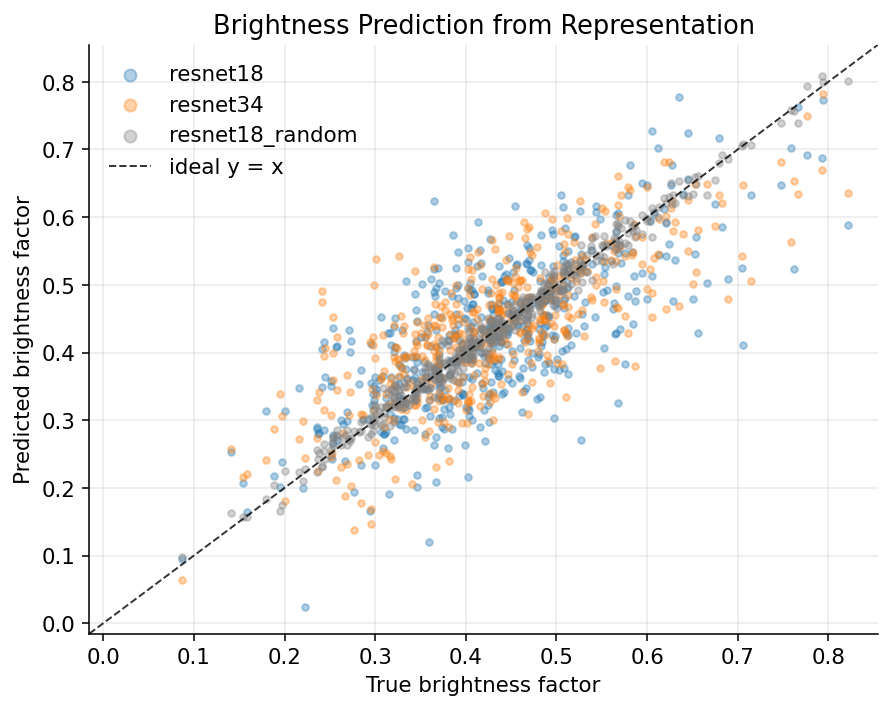

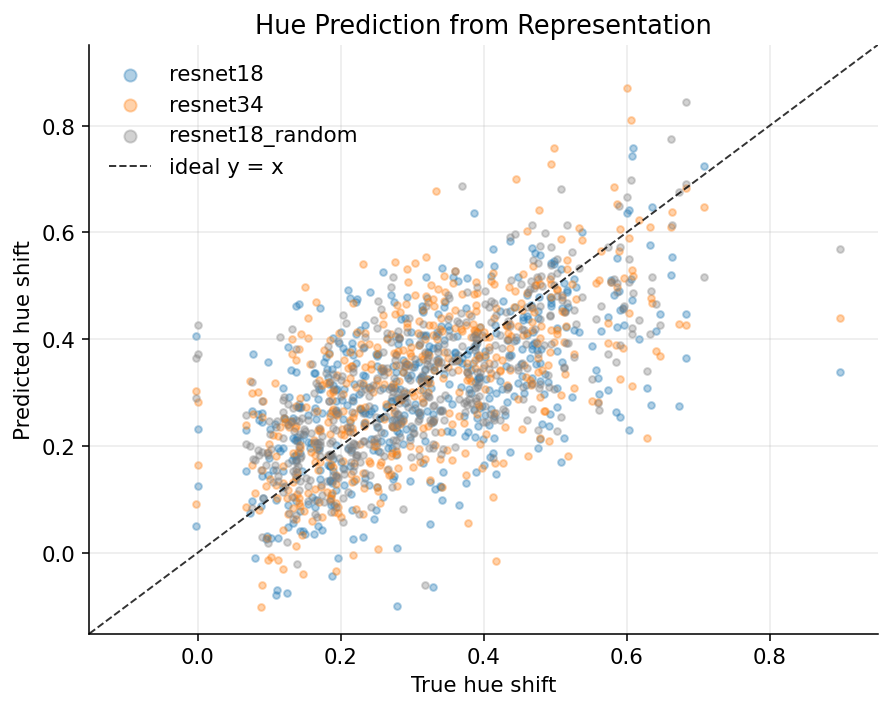

In [18]:
def plot_factor_prediction_scatter(prediction_store: Dict, factor_name: str, x_label: str, y_label: str, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    all_targets, all_predictions = [], []
    for model_name in cfg.model_names:
        data = prediction_store[(model_name, factor_name)]
        target = data["target"]
        pred = data["prediction"]
        all_targets.append(target)
        all_predictions.append(pred)
        rng = np.random.default_rng(cfg.random_seed)
        jitter = rng.normal(loc=0.0, scale=0.004, size=target.shape)
        ax.scatter(target + jitter, pred, s=12, alpha=0.35, color=model_colors[model_name], label=model_name)
    all_targets = np.concatenate(all_targets)
    all_predictions = np.concatenate(all_predictions)
    min_val = min(all_targets.min(), all_predictions.min())
    max_val = max(all_targets.max(), all_predictions.max())
    pad = 0.05 * (max_val - min_val + 1e-8)
    lo = min_val - pad
    hi = max_val + pad
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1, alpha=0.8, label="ideal y = x")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(frameon=False, markerscale=1.8)
    plt.tight_layout()
    plt.show()

plot_factor_prediction_scatter(prediction_store=prediction_store, factor_name="brightness", x_label="True brightness factor", y_label="Predicted brightness factor", title="Brightness Prediction from Representation")
plot_factor_prediction_scatter(prediction_store=prediction_store, factor_name="hue", x_label="True hue shift", y_label="Predicted hue shift", title="Hue Prediction from Representation")

### Final Interpretation
Summarize which model is best per task and print caveats about informativeness evaluation.

In [19]:
def print_final_interpretation(summary_df: pd.DataFrame) -> None:
    best_class = summary_df.sort_values("Class Test Accuracy", ascending=False).iloc[0]
    best_brightness = summary_df.sort_values("Brightness Test R2", ascending=False).iloc[0]
    best_hue = summary_df.sort_values("Hue Test R2", ascending=False).iloc[0]
    print("\n" + "=" * 80)
    print("Final interpretation")
    print("=" * 80)
    print(f"1. Most class-informative representation: {best_class['Model']} (test accuracy = {best_class['Class Test Accuracy']:.3f})")
    print(f"2. Most brightness-informative representation: {best_brightness['Model']} (test R² = {best_brightness['Brightness Test R2']:.3f})")
    print(f"3. Most hue-informative representation: {best_hue['Model']} (test R² = {best_hue['Hue Test R2']:.3f})")
    if "resnet18" in summary_df["Model"].values and "resnet18_random" in summary_df["Model"].values:
        rn18 = summary_df[summary_df["Model"] == "resnet18"].iloc[0]
        rnd = summary_df[summary_df["Model"] == "resnet18_random"].iloc[0]
        diff = rn18["Class Test Accuracy"] - rnd["Class Test Accuracy"]
        print(f"4. Pretrained ResNet18 vs random ResNet18 class accuracy difference: {diff:.3f}")
    print("\nCaveats:")
    print("- This notebook evaluates informativeness only.")
    print("- Class probing tests whether object-class information is linearly accessible.")
    print("- Brightness and hue probing test whether controlled low-level factors are decodable from z.")
    print("- This does not test invariance, equivariance, transferability, or full disentanglement.")
    print("- A representation can be informative for one factor but not another.")
    print("- A strong probe result does not prove the representation is good for every task.")
    print("=" * 80)

print_final_interpretation(summary_df)


Final interpretation
1. Most class-informative representation: resnet18 (test accuracy = 0.946)
2. Most brightness-informative representation: resnet18_random (test R² = 0.985)
3. Most hue-informative representation: resnet18_random (test R² = 0.454)
4. Pretrained ResNet18 vs random ResNet18 class accuracy difference: 0.602

Caveats:
- This notebook evaluates informativeness only.
- Class probing tests whether object-class information is linearly accessible.
- Brightness and hue probing test whether controlled low-level factors are decodable from z.
- This does not test invariance, equivariance, transferability, or full disentanglement.
- A representation can be informative for one factor but not another.
- A strong probe result does not prove the representation is good for every task.
